In [ ]:
import torch
import torch.nn.functional as F
from transformers import ViTImageProcessor, ViTModel
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
from tools.note_tools.display_tool import init_matplotlib

init_matplotlib()

# STEP 1: 加载预训练ViT模型和处理器
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(
    model_name,
    do_resize=True,
    size={"height": 224, "width": 224},
    do_rescale=True,
)

# 使用ViTModel，非分类头
model = ViTModel.from_pretrained(
    model_name,
    output_attentions=True,  # 关键：让模型返回所有层的注意力
    output_hidden_states=False
)
model.eval()  # 设为评估模式

# STEP 2: 加载并预处理图片
def load_and_preprocess_image(image_path_or_url):
    """加载图片并预处理"""
    if image_path_or_url.startswith('http'):
        response = requests.get(image_path_or_url)
        image = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        image = Image.open(image_path_or_url).convert("RGB")
    
    inputs = processor(images=image, return_tensors="pt")
    resized_image = image.resize((224, 224), Image.Resampling.LANCZOS)
    return resized_image, inputs

# image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image_url = "./assets/000000039769.jpg"
original_image, inputs = load_and_preprocess_image(image_url)

# STEP 3: 提取位置嵌入
print(model.embeddings.position_embeddings.shape)  # (1, 197, 768)
print(model.embeddings.position_embeddings)  # (1, 197, 768)

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


torch.Size([1, 197, 768])
Parameter containing:
tensor([[[ 0.0096,  0.0151, -0.2672,  ...,  0.0020, -0.0100, -0.4082],
         [ 0.1557, -0.1242,  0.4469,  ...,  0.0160, -0.0571, -0.0286],
         [ 0.0304, -0.0099,  0.2231,  ...,  0.0530,  0.0797,  0.0328],
         ...,
         [-0.0285, -0.0301, -0.3384,  ...,  0.0158,  0.0020, -0.0384],
         [-0.0883,  0.0620, -0.2314,  ...,  0.0584,  0.0558, -0.1647],
         [-0.0134,  0.0084,  0.0546,  ..., -0.0511, -0.1091, -0.1272]]],
       requires_grad=True)


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Patch嵌入网格形状: torch.Size([14, 14, 768])


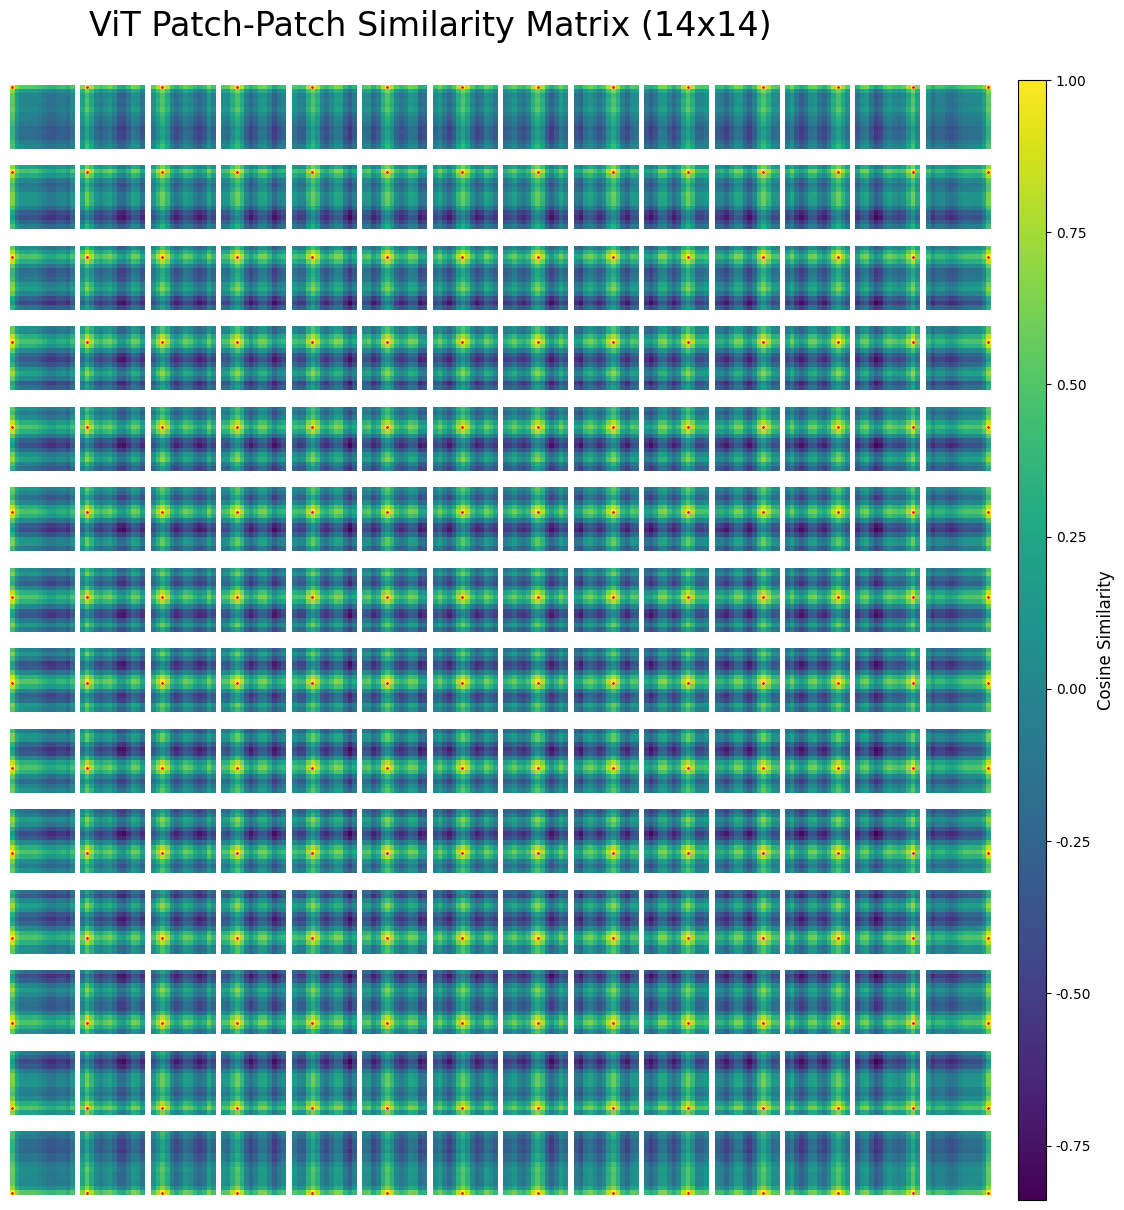


=== 相似度统计信息 ===
全局相似度范围: [-0.8391, 1.0000]
平均相似度: 0.0118
自身相似度均值: 1.0000
自身相似度标准差: 0.0000
相邻patch平均相似度: 0.7745


In [ ]:
import torch
import torch.nn.functional as F
from transformers import ViTModel
import matplotlib.pyplot as plt
import numpy as np

# 初始化matplotlib
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 1. 加载模型并提取位置嵌入
model_name = "google/vit-base-patch16-224"
model = ViTModel.from_pretrained(model_name)
model.eval()

# 获取位置嵌入并预处理
position_embeddings = model.embeddings.position_embeddings.squeeze(0).detach()  # [197, 768]
patch_embeddings = position_embeddings[1:]  # 移除CLS token，保留196个patch [196, 768]
patch_embeddings = F.normalize(patch_embeddings.float(), p=2, dim=-1)  # 归一化便于计算余弦相似度

# 重塑为14x14网格 [14, 14, 768]
patch_grid = patch_embeddings.reshape(14, 14, 768)
print(f"Patch嵌入网格形状: {patch_grid.shape}")

# 2. 计算每个patch对所有patch的相似度矩阵
# [14, 14, 196] -> 每个(i,j)位置的patch与所有196个patch的相似度
similarity_matrix = torch.matmul(patch_grid, patch_embeddings.T)  # [14, 14, 196]

# 3. 绘制14x14子图
fig, axes = plt.subplots(14, 14, figsize=(14, 14))
fig.suptitle('ViT Patch-Patch Similarity Matrix (14x14)', fontsize=24, y=0.95)

# 设置颜色归一化范围（所有子图使用相同的色标）
vmin = similarity_matrix.min().item()
vmax = similarity_matrix.max().item()
cmap = 'viridis'  # 也可以用 'coolwarm', 'RdBu_r', 'plasma'

# 遍历每个patch位置绘制子图
for i in range(14):
    for j in range(14):
        ax = axes[i, j]
        # 获取当前patch对所有patch的相似度，并重塑为14x14
        similarity_map = similarity_matrix[i, j].reshape(14, 14).cpu().numpy()
        # 绘制热力图
        im = ax.imshow(similarity_map, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.axis('off')  # 关闭坐标轴
        ax.set_aspect('equal')  # 保持正方形
        ax.scatter(j, i, color='red', s=5, marker='o', edgecolors='white', linewidths=0.2)

# 添加统一的颜色条
cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Cosine Similarity', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.subplots_adjust(left=0.2, right=0.9, top=0.9, bottom=0.1, wspace=0.1, hspace=0.1)
plt.savefig('vit_patch_similarity_14x14.png', dpi=150, bbox_inches='tight')

# 显示图片（可选，大图可能加载较慢）
plt.show()

# 4. 额外分析：统计相似度特征
print("\n=== 相似度统计信息 ===")
print(f"全局相似度范围: [{vmin:.4f}, {vmax:.4f}]")
print(f"平均相似度: {similarity_matrix.mean().item():.4f}")

# 计算对角线相似度（每个patch与自身的相似度）
diagonal_sim = []
for i in range(14):
    for j in range(14):
        # 计算当前patch在196维中的索引
        idx = i * 14 + j
        diagonal_sim.append(similarity_matrix[i, j, idx].item())

print(f"自身相似度均值: {np.mean(diagonal_sim):.4f}")  # mean: 1
print(f"自身相似度标准差: {np.std(diagonal_sim):.4f}")  # std: 0

# 计算相邻patch的平均相似度
neighbor_sim = []
for i in range(14):
    for j in range(14):
        if j < 13:  # 右邻居
            idx_current = i * 14 + j
            idx_right = i * 14 + (j + 1)
            neighbor_sim.append(similarity_matrix[i, j, idx_right].item())
        if i < 13:  # 下邻居
            idx_current = i * 14 + j
            idx_down = (i + 1) * 14 + j
            neighbor_sim.append(similarity_matrix[i, j, idx_down].item())

print(f"相邻patch平均相似度: {np.mean(neighbor_sim):.4f}")  # mean: 0.77